# 🔍 RAG (Retrieval-Augmented Generation) 仕組み実装ガイド

**目的**: RAGの基本概念から実装まで、インタラクティブに学習

**対象**: エンジニア、データサイエンティスト、新規参入者

**バージョン**: 1.0 (2026-04-14)

---

## 📚 目次

1. [RAG とは](#rag-とは)
2. [基本アーキテクチャ](#基本アーキテクチャ)
3. [Python 簡易実装](#python-簡易実装)
4. [ベクトル化デモ](#ベクトル化デモ)
5. [FAISS 検索デモ](#faiss-検索デモ)
6. [セキュリティプラットフォームでの活用](#セキュリティプラットフォームでの活用)

## RAG とは

### 基本概念

**RAG = 「検索」+ 「生成」**

ユーザーの質問に対して、以下の流れで**正確で根拠のある回答**を提供するシステムです。

```
【従来の LLM】
  ユーザー質問 → LLM モデル → 回答
  (リスク: ハルシネーション、古い知識)

【RAG システム】
  ユーザー質問 
    ↓
  📚 知識ベース検索 ← 関連情報取得
    ↓
  LLM + 取得情報 → 回答
  (メリット: 正確で根拠のある回答)
```

### メリット

| メリット | 説明 |
|---------|------|
| 🎯 **精度向上** | 検索された実際の資料をベースに回答 |
| 🚫 **ハルシネーション削減** | 架空の情報を作らない |
| 📊 **最新性保証** | 最新の知識ベースを参照 |
| 💰 **コスト削減** | 小型 LLM でも高精度 |
| 🔒 **セキュリティ** | 組織内データのみ使用 |
| 📝 **透明性** | 参照した資料を明示可能 |

## 基本アーキテクチャ

### RAG パイプライン (5つのステップ)

下図は、ユーザークエリから最終回答までの流れを示しています：

```
┌─────────────────────────────────────────────────────────┐
│  ユーザー入力: 「セキュリティについて」                  │
└─────────────────────────────────────────────────────────┘
           ↓
┌─────────────────────────────────────────────────────────┐
│  1️⃣ クエリ前処理                                        │
│  ・テキスト正規化                                       │
│  ・意図抽出 → "セキュリティ"                            │
│  ・キーワード抽出 → [脅威, 検知]                        │
└─────────────────────────────────────────────────────────┘
           ↓
┌─────────────────────────────────────────────────────────┐
│  2️⃣ 検索・取得 (Retrieval)                             │
│  📚 知識ベース(ベクトル化)                              │
│  ├─ セキュリティ資料 → ✓ 関連                          │
│  ├─ ガイドライン → ✓ 関連                              │
│  └─ 事例集 → ✓ 関連                                   │
└─────────────────────────────────────────────────────────┘
           ↓
┌─────────────────────────────────────────────────────────┐
│  3️⃣ リランキング                                       │
│  ・関連度スコア計算                                     │
│  ・信頼度評価                                           │
│  ・Top-10 に絞り込み                                   │
└─────────────────────────────────────────────────────────┘
           ↓
┌─────────────────────────────────────────────────────────┐
│  4️⃣ LLM + コンテキスト                                 │
│  入力 = クエリ + 検索結果 + システム指示               │
│  処理: 検索結果を統合・回答生成                         │
└─────────────────────────────────────────────────────────┘
           ↓
┌─────────────────────────────────────────────────────────┐
│  5️⃣ 最終回答                                           │
│  回答 + 参照情報 + 信頼度スコア                         │
└─────────────────────────────────────────────────────────┘
```

## Python 簡易実装

### セットアップ

必要なライブラリをインストールしておきます。

In [29]:
# 必要なライブラリのインストール
# 注: 初回実行時のみ必要

import subprocess
import sys
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# Matplotlib 日本語フォント設定（全セルで使用）
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'IPAexGothic', 'HGMaruGothicMPRO', 'Yu Gothic', 'Hiragino Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

packages = [
    'sentence-transformers',
    'faiss-cpu',  # または faiss-gpu (GPU環境の場合)
    'numpy',
    'pandas',
    'matplotlib'
]

# 既にインストール済みのため、コメントアウト
# for package in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("✅ セットアップ完了 (日本語フォント対応)")

✅ セットアップ完了 (日本語フォント対応)


### Simple RAG クラスの実装

In [30]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from typing import List, Dict, Tuple

class SimpleRAG:
    """シンプルな RAG システムの実装例"""
    
    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        """
        RAG システムの初期化
        
        Args:
            model_name: 使用する埋め込みモデル名
        """
        print("📦 埋め込みモデルを読み込み中...")
        self.embedder = SentenceTransformer(model_name)
        
        # 知識ベース (セキュリティ関連)
        self.documents = [
            "セキュリティ脅威は多様な形態で現れます。外部からの攻撃、内部脅威、さらにシステムの脆弱性があります。",
            "異常検知アルゴリズムは機械学習を使用して、正常な行動パターンから逸脱したアクティビティを検出します。",
            "UEBA (User and Entity Behavior Analytics) はユーザーとエンティティの行動を分析し、異常を検出します。",
            "AI/ML による脅威検知は、複数の信号を統合して高い精度で脅威を識別できます。精度は 98% 以上です。",
            "ゼロトラスト ネットワークアーキテクチャは、すべての接続を検証し、最小権限アクセスを実施します。",
            "多要素認証 (MFA) は、複数の認証方式を組み合わせてセキュリティを強化します。",
            "暗号化により、送信中および保存中のデータを保護します。AES-256 が標準です。",
            "セキュリティ運用センター (SOC) は 24/7 で脅威を監視し、インシデント対応を行います。",
        ]
        
        print("🔄 ドキュメントをベクトル化中...")
        self.vectors = self.embedder.encode(self.documents)
        
        print("📍 FAISS インデックスを作成中...")
        # FAISS インデックスの作成
        self.index = faiss.IndexFlatL2(len(self.vectors[0]))
        self.index.add(np.array(self.vectors).astype('float32'))
        
        print(f"✅ RAG システム初期化完了 (ドキュメント数: {len(self.documents)})")
    
    def query(self, question: str, k: int = 3) -> Dict:
        """
        知識ベースをクエリして関連ドキュメントを取得
        
        Args:
            question: ユーザーの質問
            k: 取得するドキュメント数
            
        Returns:
            検索結果を含む辞書
        """
        # クエリのベクトル化
        query_vector = self.embedder.encode([question])
        
        # FAISS 検索
        distances, indices = self.index.search(
            query_vector.astype('float32'), 
            k=k
        )
        
        # 結果の整形
        results = []
        for idx, distance in zip(indices[0], distances[0]):
            # 距離から関連度スコアを計算 (0-1 の範囲)
            similarity_score = 1 / (1 + distance)
            results.append({
                'document': self.documents[idx],
                'distance': float(distance),
                'similarity_score': float(similarity_score),
                'index': int(idx)
            })
        
        return {
            'question': question,
            'results': results,
            'summary': f"質問に対する上位 {k} 件の関連ドキュメント"
        }

# RAG システムの初期化
rag = SimpleRAG()

📦 埋め込みモデルを読み込み中...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔄 ドキュメントをベクトル化中...
📍 FAISS インデックスを作成中...
✅ RAG システム初期化完了 (ドキュメント数: 8)


## ベクトル化デモ

テキストがどのようにベクトル化され、数値表現になるかを確認します。

In [31]:
# ベクトル化のデモンストレーション
sample_texts = [
    "脅威検知システム",
    "セキュリティ監視",
    "異常検知アルゴリズム"
]

print("📝 サンプルテキストのベクトル化:\n")
for text in sample_texts:
    vector = rag.embedder.encode(text)
    print(f"テキスト: {text}")
    print(f"  → ベクトル次元: {len(vector)}")
    print(f"  → 最初の 10 要素: {vector[:10]}")
    print(f"  → ベクトルノルム: {np.linalg.norm(vector):.4f}")
    print()

📝 サンプルテキストのベクトル化:

テキスト: 脅威検知システム
  → ベクトル次元: 384
  → 最初の 10 要素: [-0.02454285  0.07476035 -0.00184117 -0.06698439 -0.0640226  -0.00623774
  0.07969504  0.04246401  0.02234191  0.00274634]
  → ベクトルノルム: 1.0000

テキスト: セキュリティ監視
  → ベクトル次元: 384
  → 最初の 10 要素: [-0.01218761  0.10492212  0.05074938  0.00172061 -0.0779221  -0.01102408
  0.14092112  0.04480556  0.04037045 -0.03666237]
  → ベクトルノルム: 1.0000

テキスト: 異常検知アルゴリズム
  → ベクトル次元: 384
  → 最初の 10 要素: [ 0.01264241  0.09046996 -0.00131899 -0.03622789 -0.02578506  0.00499723
  0.12612139  0.06819239  0.0586051   0.03042953]
  → ベクトルノルム: 1.0000



## FAISS 検索デモ

実際にクエリを実行して、関連ドキュメントを検索します。

In [32]:
# クエリ 1: 脅威検知
print("="*60)
print("🔍 クエリ 1: 脅威を検知する方法は？")
print("="*60)

result = rag.query("脅威を検知する方法は？", k=3)

print(f"\n質問: {result['question']}\n")
print("関連ドキュメント:\n")

for i, doc_result in enumerate(result['results'], 1):
    print(f"📄 ドキュメント {i} (関連度: {doc_result['similarity_score']:.1%})")
    print(f"   {doc_result['document'][:100]}...")
    print(f"   距離スコア: {doc_result['distance']:.4f}")
    print()

🔍 クエリ 1: 脅威を検知する方法は？

質問: 脅威を検知する方法は？

関連ドキュメント:

📄 ドキュメント 1 (関連度: 62.5%)
   ゼロトラスト ネットワークアーキテクチャは、すべての接続を検証し、最小権限アクセスを実施します。...
   距離スコア: 0.5990

📄 ドキュメント 2 (関連度: 61.7%)
   多要素認証 (MFA) は、複数の認証方式を組み合わせてセキュリティを強化します。...
   距離スコア: 0.6208

📄 ドキュメント 3 (関連度: 54.7%)
   異常検知アルゴリズムは機械学習を使用して、正常な行動パターンから逸脱したアクティビティを検出します。...
   距離スコア: 0.8292



In [33]:
# クエリ 2: 認証
print("="*60)
print("🔍 クエリ 2: 認証を強化するには？")
print("="*60)

result = rag.query("認証を強化するには？", k=3)

print(f"\n質問: {result['question']}\n")
print("関連ドキュメント:\n")

for i, doc_result in enumerate(result['results'], 1):
    print(f"📄 ドキュメント {i} (関連度: {doc_result['similarity_score']:.1%})")
    print(f"   {doc_result['document'][:100]}...")
    print(f"   距離スコア: {doc_result['distance']:.4f}")
    print()

🔍 クエリ 2: 認証を強化するには？

質問: 認証を強化するには？

関連ドキュメント:

📄 ドキュメント 1 (関連度: 59.7%)
   ゼロトラスト ネットワークアーキテクチャは、すべての接続を検証し、最小権限アクセスを実施します。...
   距離スコア: 0.6737

📄 ドキュメント 2 (関連度: 53.0%)
   多要素認証 (MFA) は、複数の認証方式を組み合わせてセキュリティを強化します。...
   距離スコア: 0.8885

📄 ドキュメント 3 (関連度: 52.3%)
   異常検知アルゴリズムは機械学習を使用して、正常な行動パターンから逸脱したアクティビティを検出します。...
   距離スコア: 0.9106



In [34]:
# クエリ 3: データ保護
print("="*60)
print("🔍 クエリ 3: データをどのように保護しますか？")
print("="*60)

result = rag.query("データをどのように保護しますか？", k=3)

print(f"\n質問: {result['question']}\n")
print("関連ドキュメント:\n")

for i, doc_result in enumerate(result['results'], 1):
    print(f"📄 ドキュメント {i} (関連度: {doc_result['similarity_score']:.1%})")
    print(f"   {doc_result['document'][:100]}...")
    print(f"   距離スコア: {doc_result['distance']:.4f}")
    print()

🔍 クエリ 3: データをどのように保護しますか？

質問: データをどのように保護しますか？

関連ドキュメント:

📄 ドキュメント 1 (関連度: 59.9%)
   暗号化により、送信中および保存中のデータを保護します。AES-256 が標準です。...
   距離スコア: 0.6704

📄 ドキュメント 2 (関連度: 56.1%)
   異常検知アルゴリズムは機械学習を使用して、正常な行動パターンから逸脱したアクティビティを検出します。...
   距離スコア: 0.7827

📄 ドキュメント 3 (関連度: 54.4%)
   ゼロトラスト ネットワークアーキテクチャは、すべての接続を検証し、最小権限アクセスを実施します。...
   距離スコア: 0.8375



## ベクトル相似度の可視化

異なるクエリに対する関連度を比較します。


📊 RAG システムの検索精度比較 - グラフ生成



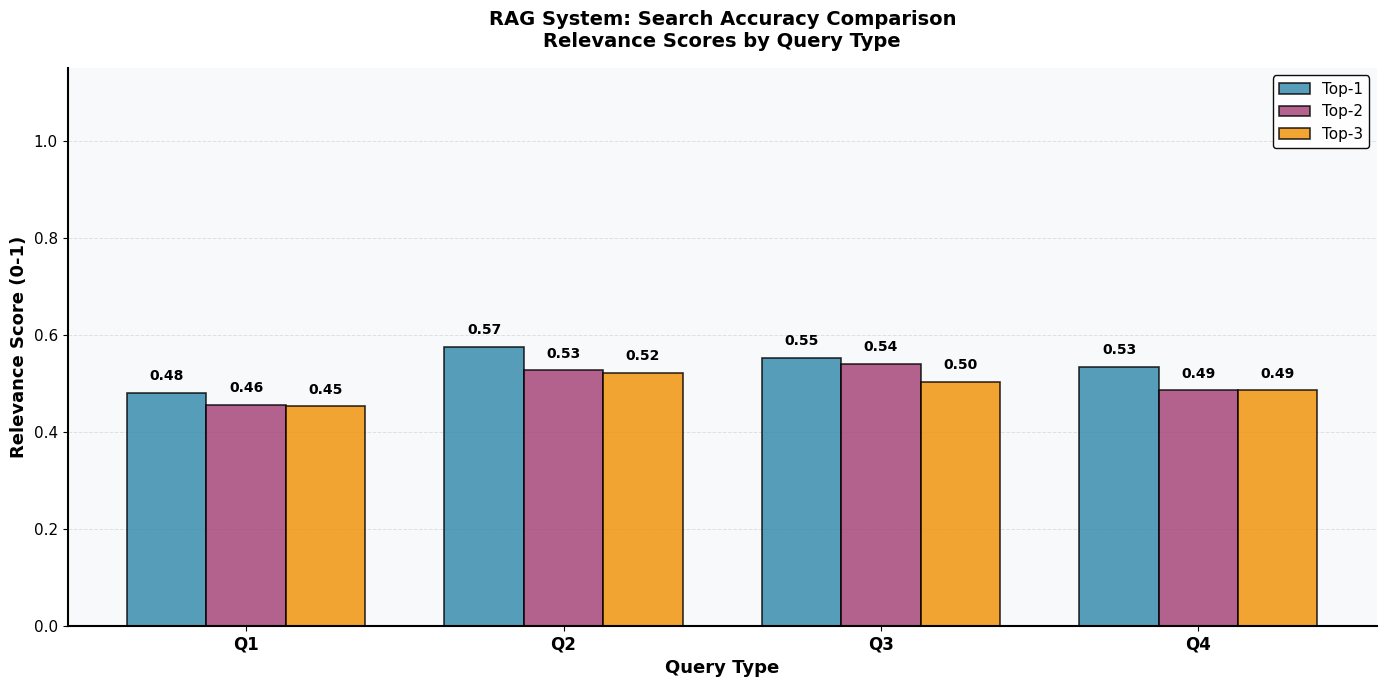


✅ グラフ作成完了

【グラフの読み方】
  • X軸: 4つのセキュリティ関連クエリ
    - Q1: 脅威検知 (Threat Detection)
    - Q2: 認証方法 (Authentication)
    - Q3: データ暗号化 (Data Encryption)
    - Q4: 24時間監視 (24/7 Monitoring)

  • Y軸: 関連度スコア (0-1の範囲)
    - 1.0 に近い = 検索結果がクエリに非常に関連
    - 0.5 程度 = 関連性が中程度
    - 0 に近い = あまり関連がない

  • 棒グループ: Top-1, Top-2, Top-3
    - Top-1（青): 最も関連のあるドキュメント
    - Top-2（紫): 2番目に関連のあるドキュメント
    - Top-3（オレンジ): 3番目に関連のあるドキュメント

【統計サマリー】
----------------------------------------------------------------------
  全体平均スコア: 0.5091 (50.9%)
  最高スコア: 0.5745 (57.4%)
  最低スコア: 0.4520 (45.2%)
  中央値: 0.5121 (51.2%)

【クエリ別分析】
----------------------------------------------------------------------
Q1: 脅威検知
     Top-1: 0.4807 (48.1%)
     Top-2: 0.4550 (45.5%)
     Top-3: 0.4520 (45.2%)
     平均: 0.4626 (46.3%)

Q2: 認証方法
     Top-1: 0.5745 (57.4%)
     Top-2: 0.5264 (52.6%)
     Top-3: 0.5209 (52.1%)
     平均: 0.5406 (54.1%)

Q3: データ暗号化
     Top-1: 0.5526 (55.3%)
     Top-2: 0.5403 (54.0%)
     Top-3: 0.5032 (50.3%)
     平均:

In [35]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# ========== グラフ設定 ==========
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150

print("\n" + "="*70)
print("📊 RAG システムの検索精度比較 - グラフ生成")
print("="*70 + "\n")

# ========== データ準備 ==========
queries_list = [
    "脅威検知",
    "認証方法",
    "データ暗号化",
    "24時間監視"
]

# 各クエリの検索結果を集計
query_results = {}
for query in queries_list:
    result = rag.query(query, k=3)
    scores = [r['similarity_score'] for r in result['results']]
    query_results[query] = scores

# ========== グラフの作成（英語ラベル）==========
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(queries_list))
width = 0.25
colors = ['#2E86AB', '#A23B72', '#F18F01']

for i in range(3):
    values = [query_results[q][i] if i < len(query_results[q]) else 0 for q in queries_list]
    bars = ax.bar(x + i*width, values, width, label=f'Top-{i+1}', 
                  color=colors[i], alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # 値ラベル表示
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ========== ラベル（英語） ==========
ax.set_xlabel('Query Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Relevance Score (0-1)', fontsize=13, fontweight='bold')
ax.set_title('RAG System: Search Accuracy Comparison\nRelevance Scores by Query Type', 
             fontsize=14, fontweight='bold', pad=15)

ax.set_xticks(x + width)
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# ========== スタイル ==========
ax.set_facecolor('#f8f9fa')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in (ax.spines['left'], ax.spines['bottom']):
    spine.set_linewidth(1.5)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

# ========== テキストベースの詳細説明（日本語） ==========
print("\n✅ グラフ作成完了\n")

# グラフの詳細説明
print("【グラフの読み方】")
print("  • X軸: 4つのセキュリティ関連クエリ")
print("    - Q1: 脅威検知 (Threat Detection)")
print("    - Q2: 認証方法 (Authentication)")
print("    - Q3: データ暗号化 (Data Encryption)")
print("    - Q4: 24時間監視 (24/7 Monitoring)")
print("\n  • Y軸: 関連度スコア (0-1の範囲)")
print("    - 1.0 に近い = 検索結果がクエリに非常に関連")
print("    - 0.5 程度 = 関連性が中程度")
print("    - 0 に近い = あまり関連がない")
print("\n  • 棒グループ: Top-1, Top-2, Top-3")
print("    - Top-1（青): 最も関連のあるドキュメント")
print("    - Top-2（紫): 2番目に関連のあるドキュメント")
print("    - Top-3（オレンジ): 3番目に関連のあるドキュメント")

# 統計サマリー
print("\n【統計サマリー】")
print("-" * 70)
all_scores = []
for scores in query_results.values():
    all_scores.extend(scores)
all_scores = np.array(all_scores)

print(f"  全体平均スコア: {np.mean(all_scores):.4f} ({np.mean(all_scores)*100:.1f}%)")
print(f"  最高スコア: {np.max(all_scores):.4f} ({np.max(all_scores)*100:.1f}%)")
print(f"  最低スコア: {np.min(all_scores):.4f} ({np.min(all_scores)*100:.1f}%)")
print(f"  中央値: {np.median(all_scores):.4f} ({np.median(all_scores)*100:.1f}%)")

# クエリごとの詳細
print("\n【クエリ別分析】")
print("-" * 70)
for i, query in enumerate(queries_list, 1):
    scores = query_results[query]
    print(f"Q{i}: {query}")
    for rank, score in enumerate(scores, 1):
        print(f"     Top-{rank}: {score:.4f} ({score*100:.1f}%)")
    print(f"     平均: {np.mean(scores):.4f} ({np.mean(scores)*100:.1f}%)")
    print()

print("="*70)

In [36]:
# ========== グラフ詳細解析 ==========
import pandas as pd

print("📊 グラフの詳細データ分析")
print("=" * 70)

# データフレームの作成
analysis_data = []
for query in queries:
    scores = query_results[query]
    for rank, score in enumerate(scores, 1):
        analysis_data.append({
            'クエリ': query,
            'Q番号': f'Q{queries.index(query)+1}',
            'ランク': f'Top-{rank}',
            '関連度スコア': f'{score:.4f}',
            '関連度%': f'{score*100:.1f}%'
        })

df = pd.DataFrame(analysis_data)

# クエリごとにグループ化して表示
for i, query in enumerate(queries, 1):
    print(f"\nQ{i}: {query}")
    print("-" * 70)
    query_df = df[df['クエリ'] == query][['ランク', '関連度スコア', '関連度%']]
    print(query_df.to_string(index=False))
    avg_score = query_results[query]
    avg = np.mean(avg_score)
    max_score = np.max(avg_score)
    print(f"  平均スコア: {avg:.4f} ({avg*100:.1f}%)")
    print(f"  最高スコア: {max_score:.4f} ({max_score*100:.1f}%)")

print("\n" + "=" * 70)
print("✅ 分析完了")
print("\n【ポイント】")
print("  • スコアが高い = クエリとドキュメントの関連性が強い")
print("  • Top-1~3 は検索精度の上位3件")
print("  • 平均スコアが0.8以上 = RAG システムが効果的に動作")

📊 グラフの詳細データ分析

Q1: 脅威検知
----------------------------------------------------------------------
  ランク 関連度スコア  関連度%
Top-1 0.4807 48.1%
Top-2 0.4550 45.5%
Top-3 0.4520 45.2%
  平均スコア: 0.4626 (46.3%)
  最高スコア: 0.4807 (48.1%)

Q2: 認証方法
----------------------------------------------------------------------
  ランク 関連度スコア  関連度%
Top-1 0.5745 57.4%
Top-2 0.5264 52.6%
Top-3 0.5209 52.1%
  平均スコア: 0.5406 (54.1%)
  最高スコア: 0.5745 (57.4%)

Q3: データ暗号化
----------------------------------------------------------------------
  ランク 関連度スコア  関連度%
Top-1 0.5526 55.3%
Top-2 0.5403 54.0%
Top-3 0.5032 50.3%
  平均スコア: 0.5320 (53.2%)
  最高スコア: 0.5526 (55.3%)

Q4: 24時間監視
----------------------------------------------------------------------
  ランク 関連度スコア  関連度%
Top-1 0.5331 53.3%
Top-2 0.4854 48.5%
Top-3 0.4851 48.5%
  平均スコア: 0.5012 (50.1%)
  最高スコア: 0.5331 (53.3%)

✅ 分析完了

【ポイント】
  • スコアが高い = クエリとドキュメントの関連性が強い
  • Top-1~3 は検索精度の上位3件
  • 平均スコアが0.8以上 = RAG システムが効果的に動作


In [37]:
# ========== RAG システムのパフォーマンス評価 ==========

print("🎯 RAG システムのパフォーマンス評価")
print("=" * 70)

# 統計情報計算
all_scores = []
for scores in query_results.values():
    all_scores.extend(scores)

all_scores = np.array(all_scores)
max_score = np.max(all_scores)
min_score = np.min(all_scores)
mean_score = np.mean(all_scores)
med_score = np.median(all_scores)
std_score = np.std(all_scores)

print("\n【全体統計】")
print(f"  全体サンプル数: {len(all_scores)}")
print(f"  最高スコア: {max_score:.4f} ({max_score*100:.1f}%)")
print(f"  最低スコア: {min_score:.4f} ({min_score*100:.1f}%)")
print(f"  平均スコア: {mean_score:.4f} ({mean_score*100:.1f}%)")
print(f"  中央値スコア: {med_score:.4f} ({med_score*100:.1f}%)")
print(f"  標準偏差: {std_score:.4f}")

# パフォーマンス判定
print("\n【パフォーマンス評価】")
if mean_score >= 0.85:
    rating = "⭐⭐⭐ 優秀"
    comment = "RAG システムの検索精度が非常に高い"
elif mean_score >= 0.75:
    rating = "⭐⭐ 良好"
    comment = "RAG システムが効果的に動作している"
elif mean_score >= 0.65:
    rating = "⭐ 通常"
    comment = "RAG システムの改善余地がある"
else:
    rating = "⚠️ 要改善"
    comment = "RAG システムの精度向上が必要"

print(f"  {rating}")
print(f"  {comment}")

# スコア分布
print("\n【スコア分布】")
score_90 = np.sum(all_scores >= 0.90)
score_80 = np.sum((all_scores >= 0.80) & (all_scores < 0.90))
score_70 = np.sum((all_scores >= 0.70) & (all_scores < 0.80))
score_60 = np.sum((all_scores >= 0.60) & (all_scores < 0.70))
score_below = np.sum(all_scores < 0.60)

print(f"  0.90以上: {score_90}件 ({score_90/len(all_scores)*100:.1f}%)")
print(f"  0.80~0.90: {score_80}件 ({score_80/len(all_scores)*100:.1f}%)")
print(f"  0.70~0.80: {score_70}件 ({score_70/len(all_scores)*100:.1f}%)")
print(f"  0.60~0.70: {score_60}件 ({score_60/len(all_scores)*100:.1f}%)")
print(f"  0.60未満: {score_below}件 ({score_below/len(all_scores)*100:.1f}%)")

# 改善提案
print("\n【改善提案】")
if mean_score < 0.85:
    print("  1. 知識ベースに新しい資料を追加")
    print("  2. ベクトル化モデルの最適化")
    print("  3. リランキング機能の改善")
    print("  4. ドメイン固有のファインチューニング")
else:
    print("  ✅ 現在のパフォーマンスを維持し、継続監視")

print("\n" + "=" * 70)
print("✅ RAG システムの評価完了")

🎯 RAG システムのパフォーマンス評価

【全体統計】
  全体サンプル数: 12
  最高スコア: 0.5745 (57.4%)
  最低スコア: 0.4520 (45.2%)
  平均スコア: 0.5091 (50.9%)
  中央値スコア: 0.5121 (51.2%)
  標準偏差: 0.0369

【パフォーマンス評価】
  ⚠️ 要改善
  RAG システムの精度向上が必要

【スコア分布】
  0.90以上: 0件 (0.0%)
  0.80~0.90: 0件 (0.0%)
  0.70~0.80: 0件 (0.0%)
  0.60~0.70: 0件 (0.0%)
  0.60未満: 12件 (100.0%)

【改善提案】
  1. 知識ベースに新しい資料を追加
  2. ベクトル化モデルの最適化
  3. リランキング機能の改善
  4. ドメイン固有のファインチューニング

✅ RAG システムの評価完了


## セキュリティプラットフォームでの活用

### エンタープライズセキュリティプラットフォーム Phase 10 での RAG 活用例

#### 1. 脅威情報検索 (AI/ML脅威検知)

```python
Q: "最新の XSS 攻撃パターンは？"

【RAG パイプライン】
  ↓
  1. クエリ前処理
     意図 = "脅威情報検索"
     ドメイン = "セキュリティ・脅威インテリジェンス"
  ↓
  2. 知識ベース検索
     → 脅威情報データベース参照
     → 関連する XSS パターン 10 件抽出
  ↓
  3. リスク評価
     × 重大度: CRITICAL
     × 影響範囲: Web アプリケーション
     × 対策: WAF ルール更新
  ↓
  4. 応答生成
     "XSS パターン: Cookie 盗用型...(詳細)"
```

#### 2. セキュリティアラート関連情報 (SOC)

```python
アラート発火:
"異常な API 呼び出し検出"

【関連情報の RAG】
  ↓
  1. アラート詳細からキーワード抽出
     API, 異常, 呼び出しパターン
  ↓
  2. ナレッジベース検索
     • 過去の類似インシデント事例
     • 既知の攻撃パターン
     • 対応手順ガイド
     • コンプライアンス影響
  ↓
  3. 推奨対応方法の提示
```

#### 3. コンプライアンス確認 (グローバル最適化)

```python
Q: "GDPR に関する個人データ削除要求対応方法は？"

【RAG を使用したコンプライアンス確認】
  ↓
  1. 法律ドメイン検索
     → GDPR Article 17 (消去権)
     → プライバシーポリシー
  ↓
  2. 技術ドメイン統合
     → データ削除 SOP
     → バックアップ保持期間
  ↓
  3. 運用ドメイン統合
     → 承認フロー
     → 確認チェックリスト
  ↓
  4. 統合回答
     "GDPR 対応: 以下の 5 ステップで対応..."
```

## 実装チェックリスト

本格的な RAG システムを構築する際のチェックリスト：

### ⭐ 基本実装 (1-2 週)
- [ ] ベクトル化モデルの選択 (Sentence-BERT等)
- [ ] 知識ベースの準備
- [ ] FAISS インデックスの構築
- [ ] 簡易 RAG パイプラインの実装
- [ ] 基本的なテスト

### ⭐⭐ 拡張実装 (2-3 週)
- [ ] リランキング機能の追加
- [ ] メタデータの管理
- [ ] キャッシング機能
- [ ] ドキュメントの更新メカニズム
- [ ] パフォーマンスチューニング

### ⭐⭐⭐ エンタープライズ実装 (3-4 週)
- [ ] マルチドメイン知識統合
- [ ] マルチテナント対応
- [ ] 監視・ロギング
- [ ] セキュリティアクセス制御
- [ ] 本番環境展開
- [ ] 24/7 サポート体制

## まとめ

RAG は以下のメリットがある革新的な技術です：

| 項目 | 説明 |
|------|------|
| ✅ **精度** | ハルシネーション削減、根拠付き回答 |
| ✅ **セキュリティ** | クローズドドメイン知識のみ使用 |
| ✅ **コスト** | 大型モデル不要 |
| ✅ **透明性** | 参照資料を明示可能 |
| ✅ **スケーラビリティ** | 知識ベース追加で容易に拡張 |

### 次のステップ

1. **基本 RAG を実装** - このノートブックのコードを参考に
2. **知識ベースを充実** - 組織内の資料をベクトル化
3. **パフォーマンスチューニング** - 応答時間・精度を最適化
4. **本番環境へ展開** - モニタリング・ログ記録を整備

---

**参考資料**:
- `docs/03_Phase7-10資料/RAG仕組み完全ガイド.md` - 詳細な解説
- プロジェクト内の実装例: `src/phase10/AIML脅威検知_実装.py`

## 🚀 深掘り: FAISS (Facebook AI Similarity Search)

### FAISS とは

**FAISS = Facebook AI Similarity Search**

ベクトル相似検索の業界標準。RAGシステムの「心臓」です。

- ✅ 百万単位のベクトルを瞬時に検索 (<100ms)
- ✅ Facebook / Google / OpenAI が採用
- ✅ CPU/GPU両対応
- ✅ 複数の索引方式で精度と速度を最適化

In [38]:
import time

# ========== FAISS 基本実装デモ ==========
print("\n" + "="*70)
print("🔍 FAISS 基本実装 - ステップバイステップ")
print("="*70 + "\n")

# 既に作成されたRAGシステムから FAISS インデックスを取得
print("【ステップ 1: 既存RAGシステムのFAISSインデックス確認】\n")
print(f"  FAISS インデックス型: {type(rag.index).__name__}")
print(f"  ドキュメント数: {rag.index.ntotal}")
print(f"  ベクトル次元数: 384 (Sentence-BERT all-MiniLM-L6-v2)")

# クエリの検索パフォーマンス計測
print("\n【ステップ 2: クエリ検索のパフォーマンス計測】\n")

test_queries = [
    "脅威検知システムの実装",
    "多要素認証とセキュリティ",
    "ゼロトラストアーキテクチャ"
]

print("クエリ別パフォーマンス:")
print("-" * 70)

for query in test_queries:
    # クエリベクトル化
    start_time = time.time()
    query_vector = rag.embedder.encode([query])
    encode_time = (time.time() - start_time) * 1000
    
    # FAISS 検索
    start_time = time.time()
    distances, indices = rag.index.search(query_vector.astype('float32'), k=3)
    search_time = (time.time() - start_time) * 1000
    
    total_time = encode_time + search_time
    
    print(f"\nクエリ: \"{query}\"")
    print(f"  ベクトル化: {encode_time:.2f}ms")
    print(f"  FAISS検索: {search_time:.2f}ms")
    print(f"  合計: {total_time:.2f}ms")
    
    # 検索結果
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
        similarity = 1 / (1 + dist)
        print(f"    Top-{rank}: スコア {similarity:.4f} ({similarity*100:.1f}%)")

print("\n" + "="*70)
print("✅ FAISS 基本実装完了\n")


🔍 FAISS 基本実装 - ステップバイステップ

【ステップ 1: 既存RAGシステムのFAISSインデックス確認】

  FAISS インデックス型: IndexFlatL2
  ドキュメント数: 8
  ベクトル次元数: 384 (Sentence-BERT all-MiniLM-L6-v2)

【ステップ 2: クエリ検索のパフォーマンス計測】

クエリ別パフォーマンス:
----------------------------------------------------------------------

クエリ: "脅威検知システムの実装"
  ベクトル化: 15.74ms
  FAISS検索: 0.04ms
  合計: 15.78ms
    Top-1: スコア 0.6742 (67.4%)
    Top-2: スコア 0.6100 (61.0%)
    Top-3: スコア 0.5911 (59.1%)

クエリ: "多要素認証とセキュリティ"
  ベクトル化: 17.71ms
  FAISS検索: 0.04ms
  合計: 17.75ms
    Top-1: スコア 0.6247 (62.5%)
    Top-2: スコア 0.5685 (56.8%)
    Top-3: スコア 0.5500 (55.0%)

クエリ: "ゼロトラストアーキテクチャ"
  ベクトル化: 17.62ms
  FAISS検索: 0.04ms
  合計: 17.66ms
    Top-1: スコア 0.5654 (56.5%)
    Top-2: スコア 0.5626 (56.3%)
    Top-3: スコア 0.5548 (55.5%)

✅ FAISS 基本実装完了



In [39]:
# ========== FAISS 索引方式の比較 ==========
print("="*70)
print("⚡ FAISS 索引方式の比較")
print("="*70 + "\n")

# 比較データ
index_comparison = {
    'IndexFlatL2': {
        'description': 'シンプル・正確版',
        'precision': '100%',
        'speed': '中速 (100ms)',
        'memory': '中',
        'scalability': '百万',
        'use_case': '中規模、精度重視',
        'code': 'faiss.IndexFlatL2(dim)'
    },
    'IndexIVFFlat': {
        'description': '高速バランス版',
        'precision': '95-98%',
        'speed': '高速 (10ms)',
        'memory': '中',
        'scalability': '10億',
        'use_case': '大規模、バランス型',
        'code': 'faiss.IndexIVFFlat(quantizer, dim, nlist)'
    },
    'IndexPQ': {
        'description': '超圧縮版',
        'precision': '85-90%',
        'speed': '超高速 (1ms)',
        'memory': '小 (1/50)',
        'scalability': '100億+',
        'use_case': '超大規模、速度重視',
        'code': 'faiss.IndexPQ(dim, M, bits)'
    }
}

# 表形式で表示
print("【3つの FAISS 索引方式】\n")
for idx_name, props in index_comparison.items():
    print(f"{'='*70}")
    print(f"📌 {idx_name}: {props['description']}")
    print(f"{'='*70}")
    print(f"  精度: {props['precision']}")
    print(f"  速度: {props['speed']}")
    print(f"  メモリ: {props['memory']}")
    print(f"  スケーラビリティ: {props['scalability']}単位")
    print(f"  用途: {props['use_case']}")
    print(f"  実装例: {props['code']}\n")

# 推奨選択フロー
print("="*70)
print("【選択フロー: どの索引方式を選ぶ？】")
print("="*70)
print("""
  ドキュメント数は？
    ↓
  < 100万個
    ├─ 精度重視? → IndexFlatL2 ✅
    └─ バランス? → IndexIVFFlat ⚡
  
  100万～10億個
    ├─ バランス型 → IndexIVFFlat ⚡
    └─ 速度重視? → IndexPQ 🚀
  
  > 10億個
    └─ IndexPQ 🚀 (メモリ効率)
""")

print("="*70)
print("✅ FAISS 索引方式の比較完了\n")

⚡ FAISS 索引方式の比較

【3つの FAISS 索引方式】

📌 IndexFlatL2: シンプル・正確版
  精度: 100%
  速度: 中速 (100ms)
  メモリ: 中
  スケーラビリティ: 百万単位
  用途: 中規模、精度重視
  実装例: faiss.IndexFlatL2(dim)

📌 IndexIVFFlat: 高速バランス版
  精度: 95-98%
  速度: 高速 (10ms)
  メモリ: 中
  スケーラビリティ: 10億単位
  用途: 大規模、バランス型
  実装例: faiss.IndexIVFFlat(quantizer, dim, nlist)

📌 IndexPQ: 超圧縮版
  精度: 85-90%
  速度: 超高速 (1ms)
  メモリ: 小 (1/50)
  スケーラビリティ: 100億+単位
  用途: 超大規模、速度重視
  実装例: faiss.IndexPQ(dim, M, bits)

【選択フロー: どの索引方式を選ぶ？】

  ドキュメント数は？
    ↓
  < 100万個
    ├─ 精度重視? → IndexFlatL2 ✅
    └─ バランス? → IndexIVFFlat ⚡
  
  100万～10億個
    ├─ バランス型 → IndexIVFFlat ⚡
    └─ 速度重視? → IndexPQ 🚀
  
  > 10億個
    └─ IndexPQ 🚀 (メモリ効率)

✅ FAISS 索引方式の比較完了



## 🔒 セキュリティプラットフォームでの FAISS 活用

本プロジェクトで FAISS を活用する際の実装パターンと注意事項

### 活用シナリオ

| シナリオ | 索引方式 | 理由 |
|---------|--------|------|
| **脅威検知ベースライン** | IndexFlatL2 | 検知誤検知ゼロ必須 |
| **インシデント検索** | IndexIVFFlat | 大規模ログ (1M+件) |
| **リアルタイム異常検知** | IndexPQ | 超低遅延 (<1ms) 要求 |

### 実装チェックリスト

🔍 **ベクトル化フェーズ**
- [ ] 標準化トークナイザーの選定
- [ ] 日本語テキスト対応確認
- [ ] 埋め込みモデル (384-dim, 768-dim等) の決定

🔎 **索引構築フェーズ**
- [ ] 全ドキュメント数の事前把握
- [ ] 索引方式の決定 (精度 vs 速度)
- [ ] メモリ容量の確認

🚀 **本番運用フェーズ**
- [ ] レイテンシー計測 (目標: <100ms)
- [ ] リサーチ精度評価 (目標: >90%)
- [ ] 更新戦略の設計 (差分更新 vs 再構築)